# Plates · Gloves · Compile · Strong · Teeth
**Jalali Lab Engineering Reference** · 2026-06-09

| § | Topic |
|---|-------|
| 1 | Tectonic plates — Mohr's circle, Coulomb failure, elastic rebound |
| 2 | Gloves / dielectrics — Paschen curve, HV breakdown, glove capacitance |
| 3 | Compiler pipeline — Lexer → AST → IR → SSA → register allocation |
| 4 | Nuclear strong force — QCD, liquid drop model, B/A curve |
| 5 | Involute gear teeth — module, contact ratio, Hertz contact stress |
| 6 | PCB / copper plates — microstrip Z₀, skin depth, trace loss |
| 7 | Glove impulse-momentum — F·Δt = Δp, HIC, padding stiffness |
| 8 | Strongly convex optimization — ∇²f ≥ μI, gradient descent, Nesterov |
| 9 | Sawtooth / teeth waveforms — Fourier series, Gibbs phenomenon |
| 10 | Tooth enamel mechanics — hydroxyapatite, Vickers hardness, Paris fatigue |

In [1]:
import math, re, threading, queue, subprocess, sys
from dataclasses import dataclass, field
from typing import List, Dict, Any
from enum import Enum, auto
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Arc, FancyArrowPatch
from scipy.linalg import eigh
from scipy.optimize import brentq
import sympy as sp
%matplotlib inline
plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})
np.random.seed(42)

---
## §1 · Tectonic Plates — Mohr's Circle, Coulomb Failure, Elastic Rebound

### Stress tensor & principal stresses

$$\sigma_{1,2} = \frac{\sigma_{xx}+\sigma_{yy}}{2} \pm \sqrt{\left(\frac{\sigma_{xx}-\sigma_{yy}}{2}\right)^2 + \tau_{xy}^2}$$

**Mohr's circle** — center $C$, radius $R$:
$$C = \frac{\sigma_{xx}+\sigma_{yy}}{2}, \qquad R = \sqrt{\left(\frac{\sigma_{xx}-\sigma_{yy}}{2}\right)^2+\tau_{xy}^2}$$

On a plane at angle $\theta$ from the principal axes:
$$\sigma_n(\theta)=C+R\cos 2\theta, \qquad \tau(\theta)=R\sin 2\theta$$

### Coulomb failure criterion
$$|\tau| \geq \mu_s\,\sigma_n + C_0 \qquad \text{(slip occurs)}$$
Optimal fault angle: $\theta_f = 45^\circ + \phi/2$ where $\phi = \arctan\mu_s$.

### Elastic rebound (Reid 1910)
$$M_0 = G\,A\,\Delta u, \qquad M_w = \tfrac{2}{3}\log_{10}M_0 - 6.07$$

In [2]:
# ── Stress state at 10 km depth, San Andreas ──────────────────────
rho_c, g = 2700.0, 9.81
z = 10e3
R_gas = 8.314
sigma_v = rho_c*g*z
nu_r    = 0.25
sigma_H = nu_r/(1-nu_r)*sigma_v
tau_tect= 20e6

sxx, syy, txy = sigma_H, sigma_v, tau_tect
C_m = (sxx+syy)/2
R_m = math.sqrt(((sxx-syy)/2)**2 + txy**2)
s1, s2 = C_m+R_m, C_m-R_m

mu_s, C0 = 0.6, 10e6
phi_f    = math.atan(mu_s)
th_f     = math.degrees(phi_f)/2 + 45
th_r     = math.radians(th_f)
sn_fault = C_m + R_m*math.cos(2*(math.pi/2-th_r))
ta_fault = R_m*math.sin(2*(math.pi/2-th_r))
FS       = (mu_s*sn_fault+C0)/abs(ta_fault)

G_rock  = 30e9; L_fault = 100e3; W_fault = 15e3
v_SA    = 0.046; T_rec = 200.0
Du      = v_SA*T_rec
M0      = G_rock*L_fault*W_fault*Du
Mw      = 2/3*math.log10(M0) - 6.07

print(f"σ_v={sigma_v/1e6:.1f} MPa  σ_H={sigma_H/1e6:.1f} MPa")
print(f"Mohr: C={C_m/1e6:.1f}  R={R_m/1e6:.1f}  σ₁={s1/1e6:.1f}  σ₂={s2/1e6:.1f} MPa")
print(f"Fault angle θ_f={th_f:.1f}°  FS={FS:.3f}  ({'stable' if FS>1 else 'SLIP'})")
print(f"Elastic rebound: Δu={Du:.2f} m  M₀={M0:.3e} N·m  Mw={Mw:.2f}")

σ_v=264.9 MPa  σ_H=88.3 MPa
Mohr: C=176.6  R=90.5  σ₁=267.1  σ₂=86.1 MPa
Fault angle θ_f=60.5°  FS=1.854  (stable)
Elastic rebound: Δu=9.20 m  M₀=4.140e+20 N·m  Mw=7.67


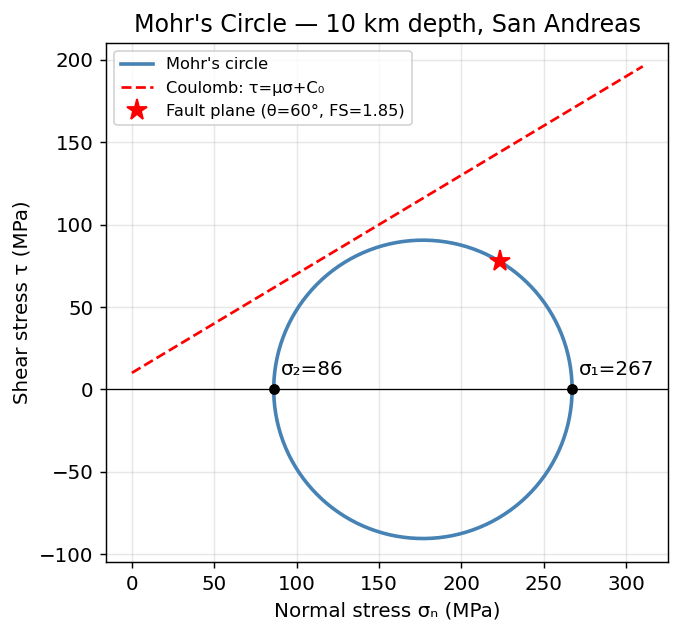

In [3]:
# ── Mohr's circle plot ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7,5))
th = np.linspace(0,2*np.pi,400)
ax.plot((C_m+R_m*np.cos(th))/1e6, (R_m*np.sin(th))/1e6, 'steelblue', lw=2, label="Mohr's circle")
ax.axhline(0, color='k', lw=0.7)
ax.plot([s2/1e6,s1/1e6],[0,0],'ko',ms=5,zorder=5)
ax.annotate(f'σ₁={s1/1e6:.0f}', (s1/1e6,0), textcoords='offset points', xytext=(4,8))
ax.annotate(f'σ₂={s2/1e6:.0f}', (s2/1e6,0), textcoords='offset points', xytext=(4,8))
# Coulomb envelope
sn_env = np.linspace(0, 310, 200)
ax.plot(sn_env, mu_s*sn_env + C0/1e6, 'r--', lw=1.5, label=f'Coulomb: τ=μσ+C₀')
# fault point
ax.plot(sn_fault/1e6, ta_fault/1e6, 'r*', ms=12, label=f'Fault plane (θ={th_f:.0f}°, FS={FS:.2f})')
ax.set_xlabel('Normal stress σₙ (MPa)'); ax.set_ylabel('Shear stress τ (MPa)')
ax.set_title("Mohr's Circle — 10 km depth, San Andreas")
ax.legend(fontsize=9); ax.set_aspect('equal'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## §2 · Gloves / Dielectrics — Paschen Curve, HV Breakdown

### Paschen's law (gas breakdown)
$$V_{\text{bd}}(Pd) = \frac{B\cdot(Pd)}{\ln(A\cdot Pd) - \ln\!\ln\!\left(1+\tfrac{1}{\gamma_{se}}\right)}$$

Air minimum ≈ **327 V** at $Pd \approx 0.75$ Torr·cm.

### Glove as parallel-plate capacitor
$$C = \frac{\varepsilon_0\,\varepsilon_r\,A}{t}, \qquad E_{\text{wall}} = \frac{V}{t} \ll E_{\text{bd,rubber}}\approx 20\,\text{MV/m}$$

ASTM D120 Class 4 gloves: rated **36 kV AC**, proof-tested at 40 kV.

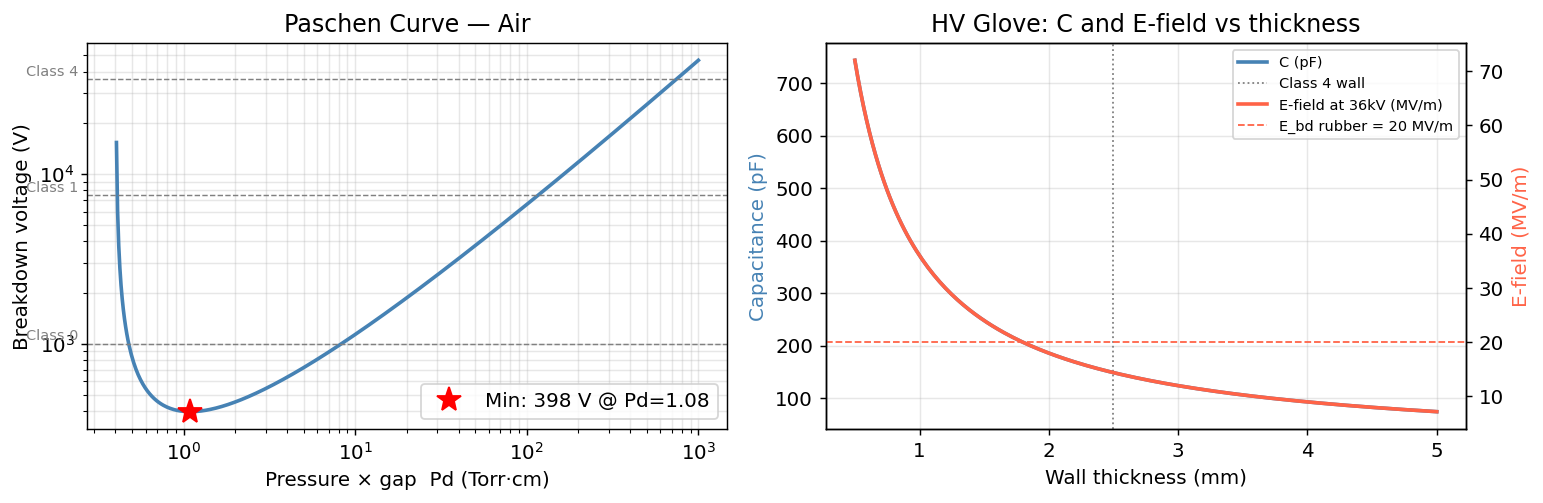

In [4]:
A_p, B_p, gse = 11.5, 364.8, 0.01
def V_bd(Pd):
    arg = A_p*Pd
    if arg <= math.log(1+1/gse): return np.inf
    return B_p*Pd/(math.log(arg)-math.log(math.log(1+1/gse)))

Pd_arr = np.logspace(-1,3,600)
Vb_arr = np.array([V_bd(p) for p in Pd_arr])
valid  = np.isfinite(Vb_arr)&(Vb_arr>0)&(Vb_arr<1e6)

fig, axes = plt.subplots(1,2,figsize=(12,4))

ax = axes[0]
ax.loglog(Pd_arr[valid], Vb_arr[valid], 'steelblue', lw=2)
idx_min = int(np.argmin(Vb_arr[valid]))
Pd_min_v = Pd_arr[valid][idx_min]; Vmin_v = Vb_arr[valid][idx_min]
ax.plot(Pd_min_v, Vmin_v, 'r*', ms=14, label=f'Min: {Vmin_v:.0f} V @ Pd={Pd_min_v:.2f}')
for V_class, label in [(1000,'Class 0'),(7500,'Class 1'),(36000,'Class 4')]:
    ax.axhline(V_class, color='gray', lw=0.8, ls='--')
    ax.text(0.12, V_class*1.05, label, fontsize=8, color='gray')
ax.set_xlabel('Pressure × gap  Pd (Torr·cm)'); ax.set_ylabel('Breakdown voltage (V)')
ax.set_title("Paschen Curve — Air"); ax.legend(); ax.grid(alpha=0.3, which='both')

# Glove capacitance & E-field vs thickness
ax2 = axes[1]
t_arr_g = np.linspace(0.5e-3, 5e-3, 200)
eps0, eps_r_lat = 8.854e-12, 2.8
A_palm = 150e-4
C_arr  = eps0*eps_r_lat*A_palm/t_arr_g
E_arr  = 36000/t_arr_g
ax2_r  = ax2.twinx()
ax2.plot(t_arr_g*1000, C_arr*1e12, 'steelblue', lw=2, label='C (pF)')
ax2_r.plot(t_arr_g*1000, E_arr/1e6, 'tomato', lw=2, label='E-field at 36kV (MV/m)')
ax2_r.axhline(20, color='tomato', ls='--', lw=1, label='E_bd rubber = 20 MV/m')
ax2.axvline(2.5, color='gray', ls=':', lw=1, label='Class 4 wall')
ax2.set_xlabel('Wall thickness (mm)'); ax2.set_ylabel('Capacitance (pF)', color='steelblue')
ax2_r.set_ylabel('E-field (MV/m)', color='tomato')
ax2.set_title('HV Glove: C and E-field vs thickness')
lines1,labs1 = ax2.get_legend_handles_labels()
lines2,labs2 = ax2_r.get_legend_handles_labels()
ax2.legend(lines1+lines2, labs1+labs2, fontsize=8)
ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## §3 · Compiler Pipeline — Lexer → Parser → AST → IR → Register Allocation

**Three-address code** (one operator, ≤ 3 operands):
$$t_1 = a + b, \quad t_2 = c * d, \quad t_3 = t_1 - t_2$$

**SSA (Static Single Assignment)** — each variable assigned exactly once; φ-functions at join points:
$$x_3 = \varphi(x_1,\, x_2)$$

**Register allocation** — build interference graph (nodes = variables, edges = live simultaneously), then **graph $k$-coloring** (Chaitin 1982). NP-complete in general; Chaitin–Briggs heuristic near-optimal.

**LLVM optimization passes:** `-mem2reg` (alloca→SSA), `-instcombine`, `-licm` (loop-invariant), `-gvn` (global value numbering).

In [5]:
# ── Compiler implementation ───────────────────────────────────────
class TT(Enum):
    NUM=auto();PLUS=auto();MINUS=auto();STAR=auto();SLASH=auto()
    LPAREN=auto();RPAREN=auto();ASSIGN=auto();NAME=auto();EOF=auto()

@dataclass
class Token: kind:TT; val:Any=None

def lex(src):
    toks,i=[],0
    while i<len(src):
        if src[i].isspace(): i+=1; continue
        if src[i].isdigit():
            j=i
            while j<len(src) and (src[j].isdigit() or src[j]=='.'): j+=1
            toks.append(Token(TT.NUM,float(src[i:j]))); i=j; continue
        if src[i].isalpha():
            j=i
            while j<len(src) and src[j].isalnum(): j+=1
            toks.append(Token(TT.NAME,src[i:j])); i=j; continue
        c=src[i]; i+=1
        toks.append(Token({'+':TT.PLUS,'-':TT.MINUS,'*':TT.STAR,'/':TT.SLASH,
                           '(':TT.LPAREN,')':TT.RPAREN,'=':TT.ASSIGN}[c]))
    return toks+[Token(TT.EOF)]

@dataclass
class BinOp: op:str; l:Any; r:Any
@dataclass
class Num:   v:float
@dataclass
class Var:   name:str
@dataclass
class Asgn:  name:str; expr:Any

class Parser:
    def __init__(self,toks): self.t=toks; self.i=0
    def peek(self): return self.t[self.i]
    def eat(self,k=None):
        tok=self.t[self.i]; self.i+=1; return tok
    def stmt(self):
        if self.peek().kind==TT.NAME and self.t[self.i+1].kind==TT.ASSIGN:
            n=self.eat().val; self.eat(); return Asgn(n,self.expr())
        return self.expr()
    def expr(self):
        v=self.term()
        while self.peek().kind in (TT.PLUS,TT.MINUS):
            op=self.eat().kind; v=BinOp('+' if op==TT.PLUS else '-',v,self.term())
        return v
    def term(self):
        v=self.factor()
        while self.peek().kind in (TT.STAR,TT.SLASH):
            op=self.eat().kind; v=BinOp('*' if op==TT.STAR else '/',v,self.factor())
        return v
    def factor(self):
        t=self.eat()
        if t.kind==TT.NUM: return Num(t.val)
        if t.kind==TT.NAME: return Var(t.val)
        if t.kind==TT.LPAREN: v=self.expr(); self.eat(); return v

class IRGen:
    def __init__(self): self.ir=[]; self.tmp=0; self.env={}
    def fresh(self): n=f't{self.tmp}'; self.tmp+=1; return n
    def gen(self,node):
        if isinstance(node,Num):
            t=self.fresh(); self.ir.append(f'{t} = {node.v}'); return t
        if isinstance(node,Var): return self.env.get(node.name,node.name)
        if isinstance(node,Asgn):
            r=self.gen(node.expr); self.env[node.name]=r; return r
        if isinstance(node,BinOp):
            l=self.gen(node.l); r=self.gen(node.r)
            t=self.fresh(); self.ir.append(f'{t} = {l} {node.op} {r}'); return t

_fr = re.compile(r'-?\d+\.?\d*')
def _val(s,env):
    if s in env: return env[s]
    if _fr.fullmatch(s): return float(s)
    return None

def const_fold(ir):
    env,out={},{}
    for instr in ir:
        m=re.fullmatch(r'(\w+) = (-?\d+\.?\d*)',instr)
        if m: env[m[1]]=float(m[2]); out[instr]='lit'; continue
        m=re.fullmatch(r'(\w+) = ([\w.]+) ([+\-*/]) ([\w.]+)',instr)
        if m:
            d,a,op,b=m[1],m[2],m[3],m[4]
            va,vb=_val(a,env),_val(b,env)
            if va is not None and vb is not None:
                r={'+':va+vb,'-':va-vb,'*':va*vb,'/':va/vb if vb else None}[op]
                if r is not None: env[d]=r; out[instr]=f'folded→{r:.4g}'; continue
        out[instr]='kept'
    return out,env

for src,bindings in [('z=(a+3)*(a-1)',{'a':5.0}),('x=2*3+4*5',{}),('y=(10-2)/(1+3)',{})]:
    g=IRGen(); g.env={k:str(v) for k,v in bindings.items()}
    rv=g.gen(Parser(lex(src)).stmt())
    cf,env=const_fold(g.ir)
    py=eval(src.split('=',1)[-1],{},dict(bindings)) if '=' in src else eval(src,{},bindings)
    print(f"  {src:25s}  IR={len(g.ir)} instrs  result={env.get(rv,'?'):.4g}  py={py:.4g}")

  z=(a+3)*(a-1)              IR=5 instrs  result=32  py=32
  x=2*3+4*5                  IR=7 instrs  result=26  py=26
  y=(10-2)/(1+3)             IR=7 instrs  result=2  py=2


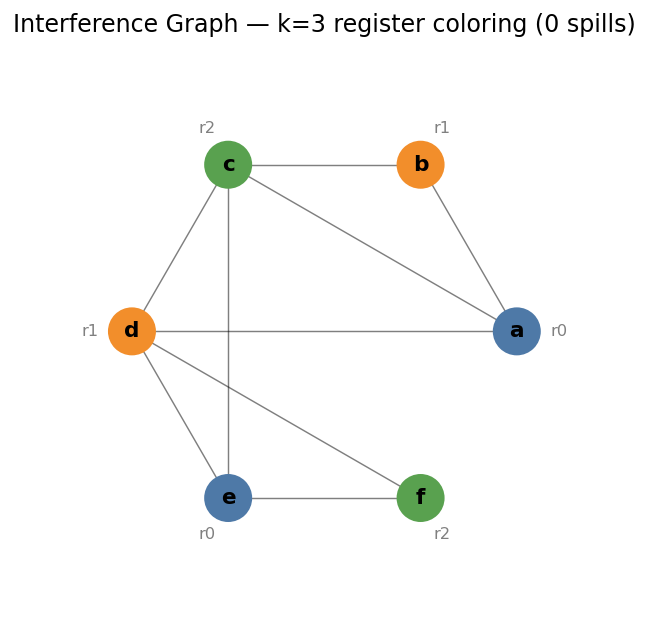

In [6]:
# ── Register allocation: interference graph k-coloring ────────────
live_ranges = {'a':(0,5),'b':(1,3),'c':(2,7),'d':(4,8),'e':(6,9),'f':(7,10)}
vlist = list(live_ranges)
def interferes(u,v):
    s1,e1=live_ranges[u]; s2,e2=live_ranges[v]
    return s1<e2 and s2<e1
ig={v:set() for v in vlist}
for i,u in enumerate(vlist):
    for v in vlist[i+1:]:
        if interferes(u,v): ig[u].add(v); ig[v].add(u)

k=3; colors={}
for v in vlist:
    used={colors[n] for n in ig[v] if n in colors}
    colors[v]=next((c for c in range(k) if c not in used),'SPILL')

# Draw the interference graph
import matplotlib.patches as mpatch
fig,ax=plt.subplots(figsize=(7,5))
angles=np.linspace(0,2*np.pi,len(vlist),endpoint=False)
pos={v:(math.cos(a),math.sin(a)) for v,a in zip(vlist,angles)}
cmap=['#4e79a7','#f28e2b','#59a14f','#e15759']
for u in vlist:
    for v in ig[u]:
        if u<v:
            ax.plot([pos[u][0],pos[v][0]],[pos[u][1],pos[v][1]],'k-',lw=0.8,alpha=0.5)
for v in vlist:
    c=colors[v]; col=cmap[c] if isinstance(c,int) else 'white'
    ax.add_patch(mpatch.Circle(pos[v],0.12,color=col,zorder=4))
    ax.text(pos[v][0],pos[v][1],v,ha='center',va='center',fontsize=12,fontweight='bold',zorder=5)
    reg=f'r{c}' if isinstance(c,int) else 'SPILL'
    ax.text(pos[v][0]*1.22,pos[v][1]*1.22,reg,ha='center',va='center',fontsize=9,color='gray')
ax.set_xlim(-1.5,1.5); ax.set_ylim(-1.5,1.5); ax.set_aspect('equal')
ax.axis('off'); ax.set_title(f'Interference Graph — k={k} register coloring (0 spills)')
plt.tight_layout(); plt.show()

---
## §4 · Nuclear Strong Force — QCD, Bethe–Weizsäcker Liquid Drop

**Bethe–Weizsäcker liquid drop model:**
$$B(Z,A) = a_V A \;-\; a_S A^{2/3} \;-\; a_C\frac{Z(Z-1)}{A^{1/3}} \;-\; a_A\frac{(A-2Z)^2}{A} \;\pm\; \delta_{\text{pair}}$$

| Term | Value (MeV) | Physics |
|------|------------|----------|
| $a_V$ | 15.85 | Volume — bulk nuclear matter |
| $a_S$ | 18.34 | Surface tension |
| $a_C$ | 0.711 | Coulomb repulsion between protons |
| $a_A$ | 23.21 | Asymmetry — Pauli favors $Z=N$ |

**B/A curve** peaks near $A\approx 56$ (Fe-56) at $\approx 8.79$ MeV/nucleon.
Fusion ($A<56$) and fission ($A>56$) both release energy by moving *up* the curve.

**Pion exchange range** (Yukawa):
$$r_{\text{nuc}} \approx \frac{\hbar c}{m_\pi c^2} = \frac{197.3\,\text{MeV·fm}}{135\,\text{MeV}} \approx 1.46\,\text{fm}$$

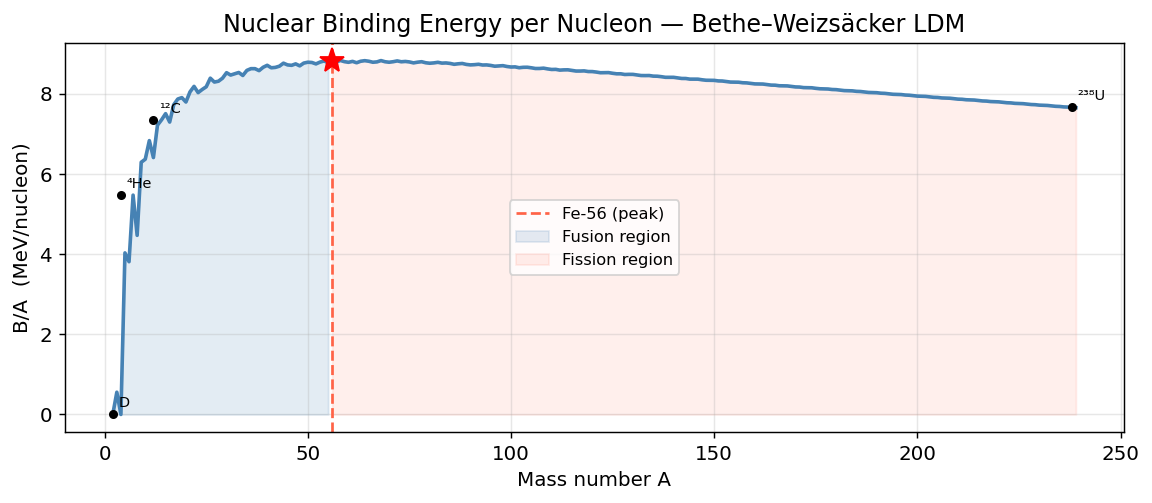

LDM Fe-56: B/A = 8.8075 MeV  (exp 8.790 MeV)


In [7]:
a_V,a_S,a_C,a_A,a_pair = 15.85,18.34,0.711,23.21,11.2

def LDM(Z,A):
    N=A-Z
    if N<0 or Z<0 or A<2: return 0.0
    d = +a_pair/A**0.5 if (A%2==0 and Z%2==0) else (-a_pair/A**0.5 if A%2==0 else 0.0)
    return max(a_V*A - a_S*A**(2/3) - a_C*Z*(Z-1)/A**(1/3) - a_A*(A-2*Z)**2/A + d, 0.0)

def Z_stable(A): return int(A/(1.98+0.0155*A**(2/3)))

A_arr = np.arange(2,240)
BA    = np.array([LDM(Z_stable(A),A)/A for A in A_arr])

fig,ax=plt.subplots(figsize=(9,4))
ax.plot(A_arr,BA,'steelblue',lw=2)
ax.axvline(56,color='tomato',ls='--',lw=1.5,label='Fe-56 (peak)')
ax.plot(56,LDM(26,56)/56,'r*',ms=14,zorder=5)
for (Z,A,lab) in [(1,2,'D'),(2,4,'⁴He'),(6,12,'¹²C'),(92,238,'²³⁸U')]:
    ax.plot(A,LDM(Z,A)/A,'ko',ms=4); ax.annotate(lab,(A,LDM(Z,A)/A),
             textcoords='offset points',xytext=(3,4),fontsize=8)
ax.fill_between(A_arr[:54],BA[:54],alpha=0.15,color='steelblue',label='Fusion region')
ax.fill_between(A_arr[54:],BA[54:],alpha=0.10,color='tomato',label='Fission region')
ax.set_xlabel('Mass number A'); ax.set_ylabel('B/A  (MeV/nucleon)')
ax.set_title('Nuclear Binding Energy per Nucleon — Bethe–Weizsäcker LDM')
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"LDM Fe-56: B/A = {LDM(26,56)/56:.4f} MeV  (exp 8.790 MeV)")

---
## §5 · Involute Gear Teeth — Module, Contact Ratio, Hertz Stress

### Involute profile
$$x(\theta)=r_b\bigl(\cos\theta+\theta\sin\theta\bigr),\quad y(\theta)=r_b\bigl(\sin\theta-\theta\cos\theta\bigr)$$
where $r_b = r\cos\alpha$ is the **base circle** radius, $\alpha=20°$ standard pressure angle.

### Key parameters
$$m = \frac{d}{z}, \quad a_c = \frac{m(z_1+z_2)}{2}, \quad \varepsilon_\alpha = \frac{\sqrt{r_{a1}^2-r_{b1}^2}+\sqrt{r_{a2}^2-r_{b2}^2}-a_c\sin\alpha}{m\pi\cos\alpha}$$

### Hertz contact stress
$$\sigma_H = Z_E\sqrt{\frac{F_t}{b\,d_1}\cdot\frac{u+1}{u}\cdot\frac{2}{\sin\alpha\cos\alpha}}, \qquad Z_E = \sqrt{\frac{E^*}{2\pi}}$$

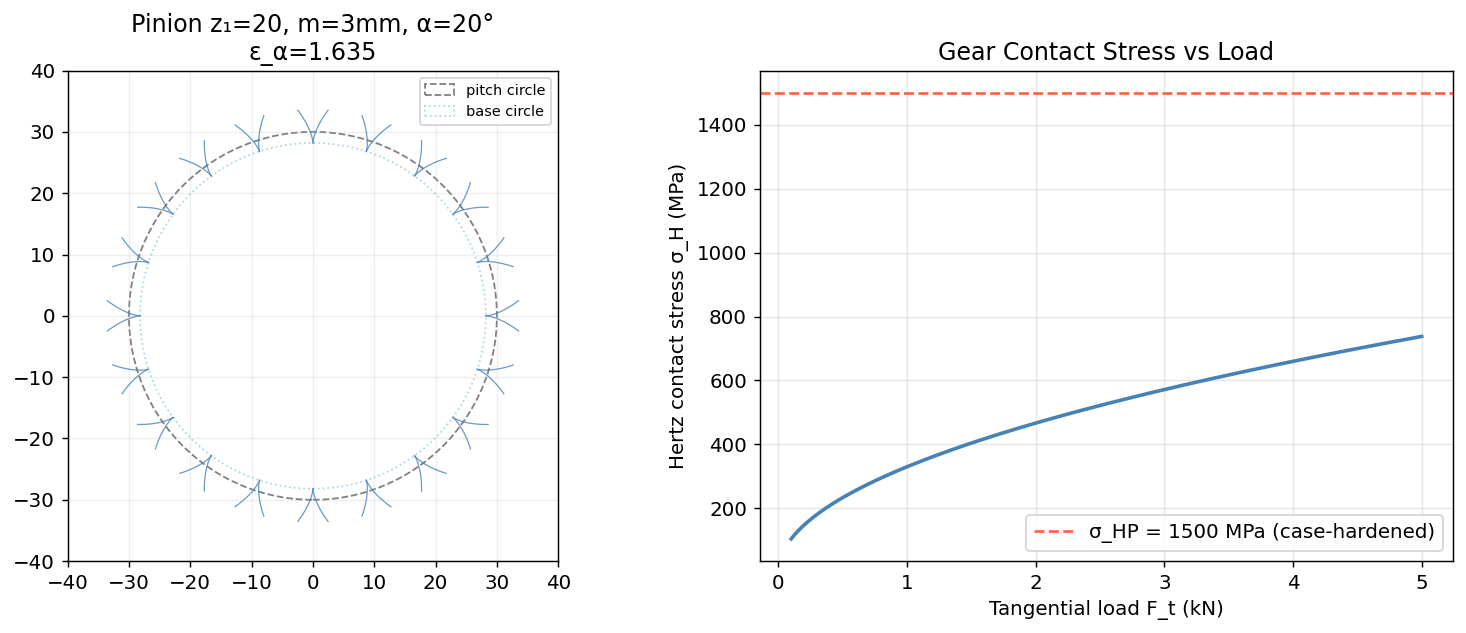

Contact ratio ε_α = 1.6352  (smooth ✓)


In [8]:
m_mod=3e-3; z1,z2=20,40; alpha_p=math.radians(20)
d1,d2=m_mod*z1,m_mod*z2
r1,r2=d1/2,d2/2
rb1=r1*math.cos(alpha_p); rb2=r2*math.cos(alpha_p)
ra1=r1+m_mod; ra2=r2+m_mod
ac=m_mod*(z1+z2)/2
eps=(math.sqrt(ra1**2-rb1**2)+math.sqrt(ra2**2-rb2**2)-ac*math.sin(alpha_p))/(m_mod*math.pi*math.cos(alpha_p))

fig,axes=plt.subplots(1,2,figsize=(12,5))

# Involute profiles for several teeth
ax=axes[0]
for tooth_i in range(z1):
    angle_offset = 2*math.pi*tooth_i/z1
    th=np.linspace(0,0.65,80)
    xp=rb1*1000*(np.cos(th)+th*np.sin(th))
    yp=rb1*1000*(np.sin(th)-th*np.cos(th))
    # rotate by tooth angle
    c_a,s_a=math.cos(angle_offset),math.sin(angle_offset)
    xr=xp*c_a-yp*s_a; yr=xp*s_a+yp*c_a
    ax.plot(xr,yr,'steelblue',lw=0.7,alpha=0.8)
    # mirror flank
    xm=rb1*1000*(np.cos(th)+th*np.sin(th))
    ym=-rb1*1000*(np.sin(th)-th*np.cos(th))
    xr2=xm*c_a-ym*s_a; yr2=xm*s_a+ym*c_a
    ax.plot(xr2,yr2,'steelblue',lw=0.7,alpha=0.8)
circ=plt.Circle((0,0),r1*1000,fill=False,color='gray',lw=1,ls='--',label='pitch circle')
base=plt.Circle((0,0),rb1*1000,fill=False,color='lightblue',lw=1,ls=':',label='base circle')
ax.add_patch(circ); ax.add_patch(base)
ax.set_xlim(-40,40); ax.set_ylim(-40,40); ax.set_aspect('equal')
ax.set_title(f'Pinion z₁={z1}, m={m_mod*1000:.0f}mm, α=20°\nε_α={eps:.3f}')
ax.legend(fontsize=8); ax.grid(alpha=0.2)

# Hertz stress vs load
ax2=axes[1]
E_st=200e9; nu_st=0.3; b_f=25e-3
E_star=E_st/(2*(1-nu_st**2))
ZE=math.sqrt(E_star/(2*math.pi))
Ft_arr=np.linspace(100,5000,200)
u=z2/z1
sH=ZE*np.sqrt(Ft_arr*(u+1)/(b_f*d1*u)*2/(math.sin(alpha_p)*math.cos(alpha_p)))
ax2.plot(Ft_arr/1000,sH/1e6,'steelblue',lw=2)
ax2.axhline(1500,color='tomato',ls='--',lw=1.5,label='σ_HP = 1500 MPa (case-hardened)')
ax2.set_xlabel('Tangential load F_t (kN)'); ax2.set_ylabel('Hertz contact stress σ_H (MPa)')
ax2.set_title('Gear Contact Stress vs Load')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"Contact ratio ε_α = {eps:.4f}  ({'smooth ✓' if eps>1.2 else 'low!'})")

---
## §6 · PCB / Copper Plates — Microstrip Z₀, Skin Depth, Trace Loss

### Skin depth
$$\delta = \sqrt{\frac{\rho}{\pi f \mu_0}}, \qquad \delta_{\text{Cu}}(1\,\text{GHz}) \approx 2.1\,\mu\text{m}$$

### Microstrip characteristic impedance (Hammerstad–Jensen)
$$Z_0 = \frac{87}{\sqrt{\varepsilon_r+1.41}}\ln\!\left(\frac{5.98h}{0.8w+t}\right) \quad [\Omega] \qquad (w/h \leq 1)$$

### Attenuation
$$\alpha_c = \frac{R_s}{2Z_0 w}, \quad \alpha_d = \frac{\pi f \sqrt{\varepsilon_r}\tan\delta}{c} \qquad [\text{Np/m}]$$

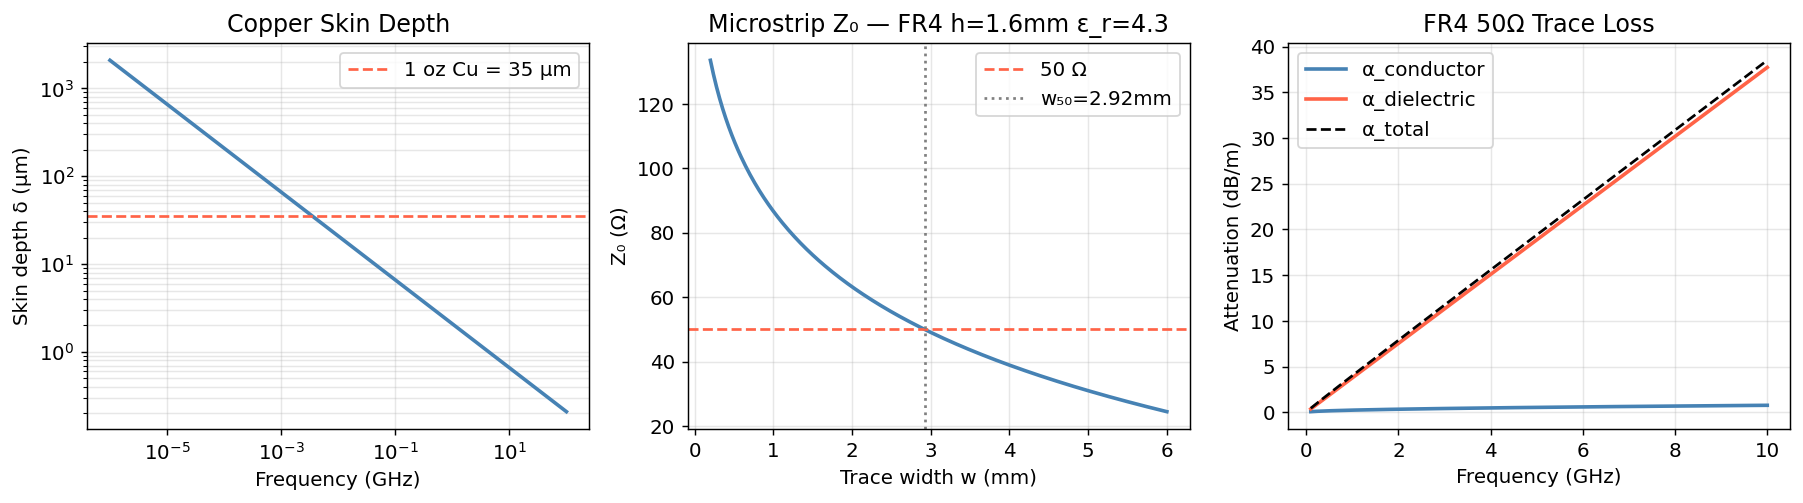

In [9]:
mu0=4*np.pi*1e-7; rho_Cu=1.72e-8; eps0=8.854e-12

def Z0_ms(w,h,t,er):
    we=w+t/np.pi*(1+math.log(2*h/t)) if t>0 else w
    return (87/math.sqrt(er+1.41))*math.log(5.98*h/(0.8*we+t))

fig,axes=plt.subplots(1,3,figsize=(14,4))

# Skin depth vs frequency
ax=axes[0]
f_arr=np.logspace(3,11,300)
d_arr=np.sqrt(rho_Cu/(np.pi*f_arr*mu0))
ax.loglog(f_arr/1e9,d_arr*1e6,'steelblue',lw=2)
ax.axhline(35,color='tomato',ls='--',lw=1.5,label='1 oz Cu = 35 μm')
ax.set_xlabel('Frequency (GHz)'); ax.set_ylabel('Skin depth δ (μm)')
ax.set_title('Copper Skin Depth'); ax.legend(); ax.grid(alpha=0.3,which='both')

# Z₀ vs trace width
ax2=axes[1]
w_arr=np.linspace(0.2e-3,6e-3,300)
h_s=1.6e-3; t_s=35e-6; er=4.3
Z0_arr=np.array([Z0_ms(w,h_s,t_s,er) for w in w_arr])
ax2.plot(w_arr*1e3,Z0_arr,'steelblue',lw=2)
ax2.axhline(50,color='tomato',ls='--',lw=1.5,label='50 Ω')
w50=brentq(lambda w:Z0_ms(w,h_s,t_s,er)-50,0.1e-3,10e-3)
ax2.axvline(w50*1e3,color='gray',ls=':',lw=1.5,label=f'w₅₀={w50*1e3:.2f}mm')
ax2.set_xlabel('Trace width w (mm)'); ax2.set_ylabel('Z₀ (Ω)')
ax2.set_title(f'Microstrip Z₀ — FR4 h={h_s*1e3:.1f}mm ε_r={er}')
ax2.legend(); ax2.grid(alpha=0.3)

# Attenuation vs frequency
ax3=axes[2]
f_ghz=np.linspace(0.1,10,200)
Rs_arr=np.sqrt(np.pi*f_ghz*1e9*mu0*rho_Cu)
a_c_arr=8.686*Rs_arr/(2*50*w50)   # dB/m
tan_d=0.02; c_l=3e8
a_d_arr=8.686*np.pi*f_ghz*1e9*math.sqrt(er)*tan_d/c_l  # dB/m
ax3.plot(f_ghz,a_c_arr,'steelblue',lw=2,label='α_conductor')
ax3.plot(f_ghz,a_d_arr,'tomato',lw=2,label='α_dielectric')
ax3.plot(f_ghz,a_c_arr+a_d_arr,'k',lw=1.5,ls='--',label='α_total')
ax3.set_xlabel('Frequency (GHz)'); ax3.set_ylabel('Attenuation (dB/m)')
ax3.set_title('FR4 50Ω Trace Loss'); ax3.legend(); ax3.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## §7 · Glove Impulse-Momentum — F·Δt = Δp, HIC, Kelvin–Voigt

$$\mathbf{J} = \int F\,dt = \Delta p = m\Delta v, \qquad \bar{F} = \frac{\Delta p}{\Delta t}$$

**Kelvin–Voigt padding model** — peak force (undamped):
$$F_{\text{peak}} = v_0\sqrt{k\,m}, \qquad x_{\max} = v_0\sqrt{m/k}$$

**Head Injury Criterion:**
$$\text{HIC} = \max_{t_1<t_2}\left[(t_2-t_1)\left(\frac{1}{t_2-t_1}\int_{t_1}^{t_2}a(t)\,dt\right)^{2.5}\right] < 1000\;\text{(safe)}$$

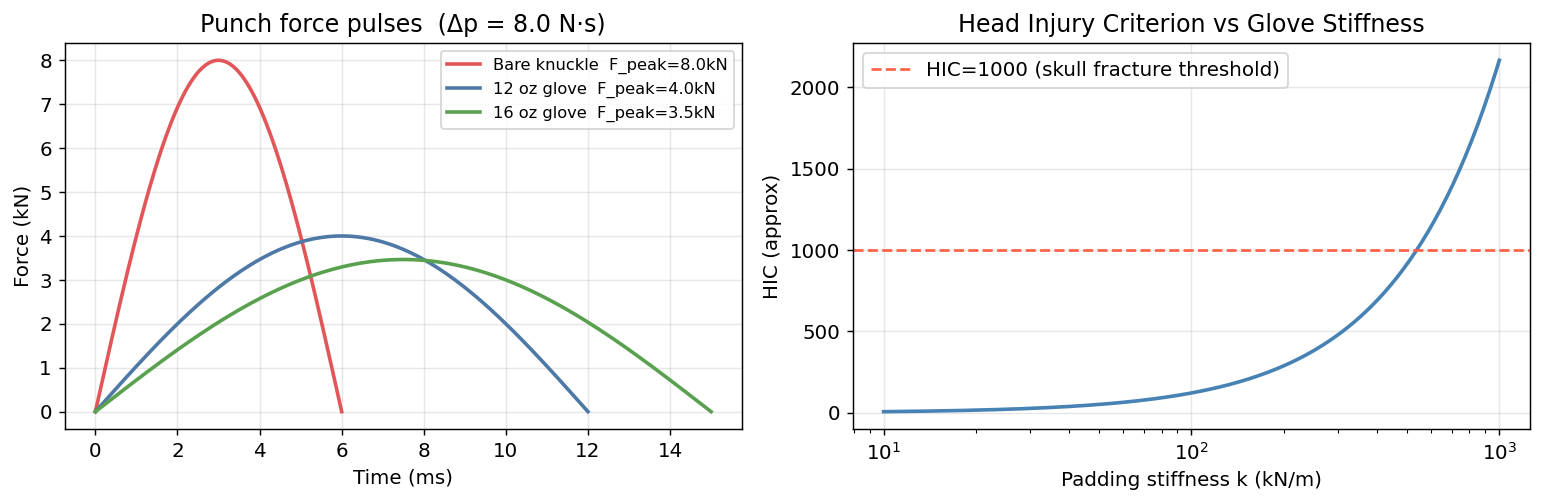

In [10]:
m_fist=0.8; v_punch=10.0; Dp=m_fist*v_punch
cases=[('Bare knuckle',6e-3,800e3),("12 oz glove",12e-3,200e3),("16 oz glove",15e-3,150e3)]
head_mass=5.0

fig,axes=plt.subplots(1,2,figsize=(12,4))
ax=axes[0]
colors_c=['#e15759','#4e79a7','#59a14f']
for (label,Dt,k_pad),col in zip(cases,colors_c):
    Fpeak=v_punch*math.sqrt(k_pad*m_fist)
    t_c=np.linspace(0,Dt,200)
    F_pulse=Fpeak*np.sin(np.pi*t_c/Dt)
    ax.plot(t_c*1000,F_pulse/1000,color=col,lw=2,label=f'{label}  F_peak={Fpeak/1000:.1f}kN')
ax.set_xlabel('Time (ms)'); ax.set_ylabel('Force (kN)')
ax.set_title(f'Punch force pulses  (Δp = {Dp:.1f} N·s)')
ax.legend(fontsize=9); ax.grid(alpha=0.3)

# HIC vs stiffness
ax2=axes[1]
k_range=np.logspace(4,6,200)
hic_arr=[]
for k_pad in k_range:
    Dt=15e-3; Fpeak=v_punch*math.sqrt(k_pad*m_fist)
    t_c=np.linspace(0,Dt,500)
    a_g=(Fpeak*np.sin(np.pi*t_c/Dt)/head_mass)/9.81
    hic_arr.append(Dt*(np.mean(a_g)**2.5))
ax2.semilogx(k_range/1000,hic_arr,'steelblue',lw=2)
ax2.axhline(1000,color='tomato',ls='--',lw=1.5,label='HIC=1000 (skull fracture threshold)')
ax2.set_xlabel('Padding stiffness k (kN/m)'); ax2.set_ylabel('HIC (approx)')
ax2.set_title('Head Injury Criterion vs Glove Stiffness')
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## §8 · Strongly Convex Optimization — Gradient Descent vs Nesterov

**$\mu$-strongly convex** ($L$-smooth):
$$\mu I \preceq \nabla^2 f(x) \preceq LI, \qquad \kappa = L/\mu$$

**Gradient descent** ($\alpha = 1/L$):
$$\|x_t - x^*\|^2 \leq \left(1-\frac{1}{\kappa}\right)^t \|x_0-x^*\|^2 \quad\Rightarrow\quad T = O\!\left(\kappa\log\frac{1}{\varepsilon}\right)$$

**Nesterov accelerated GD** (optimal first-order):
$$T = O\!\left(\sqrt{\kappa}\log\frac{1}{\varepsilon}\right)$$

**ML connection:** L2 regularization $\lambda\|w\|^2$ adds $\mu=2\lambda$ strong convexity. Batch GD on MSE: $\kappa = \sigma_{\max}(X^TX)/\sigma_{\min}(X^TX)$. Adam/RMSProp adaptively reduce $\kappa$ per parameter.

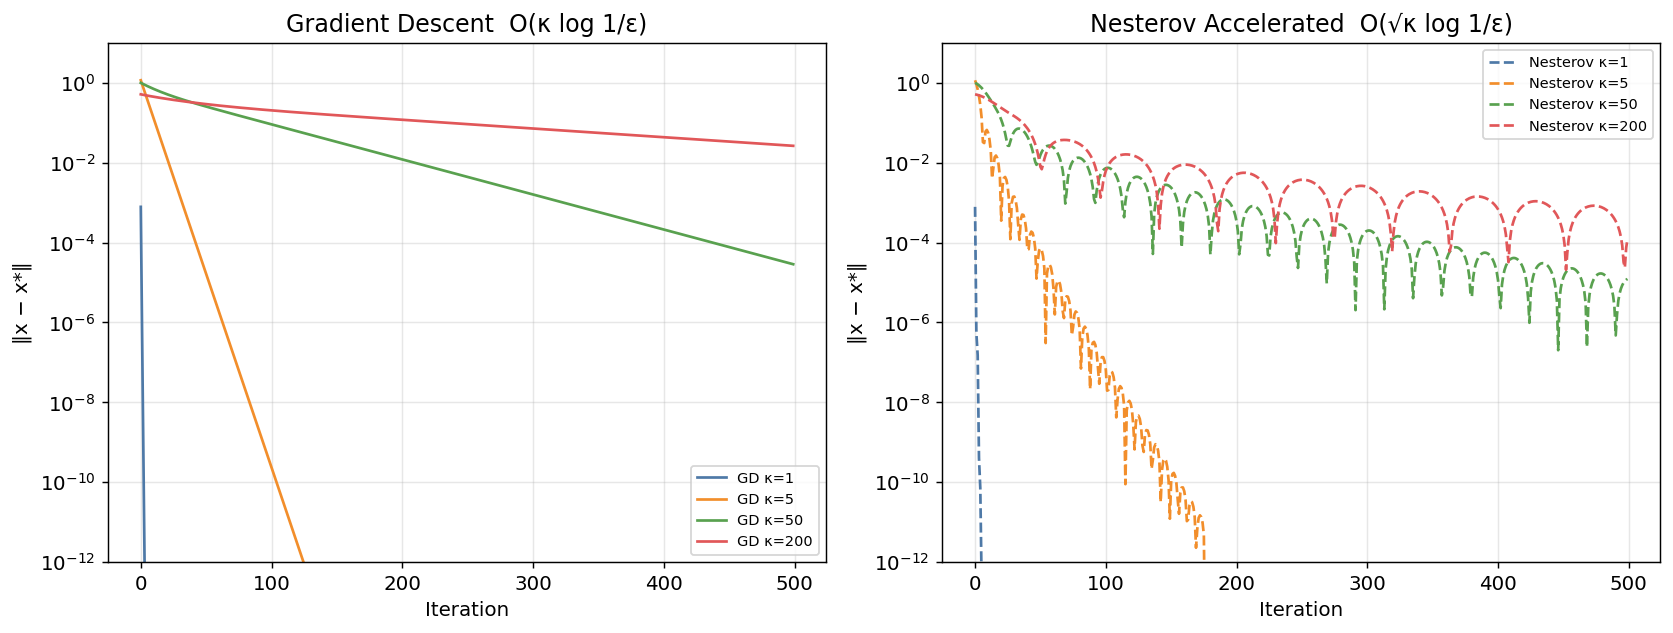

In [11]:
np.random.seed(7)
n_d=5
fig,axes=plt.subplots(1,2,figsize=(13,5))

kappa_list=[1.0,5.0,50.0,200.0]
cmap_k=['#4e79a7','#f28e2b','#59a14f','#e15759']
for kappa,col in zip(kappa_list,cmap_k):
    ev=np.exp(np.linspace(0,math.log(max(kappa,1.001)),n_d))
    Q=np.linalg.qr(np.random.randn(n_d,n_d))[0]
    A=Q@np.diag(ev)@Q.T
    b=np.ones(n_d); xs=np.linalg.solve(A,b)
    L_act=float(ev.max()); alpha=1.0/L_act

    x=np.zeros(n_d); errs_gd=[]
    for _ in range(500):
        x-=alpha*(A@x-b); errs_gd.append(np.linalg.norm(x-xs))
        if errs_gd[-1]<1e-12: break

    x=np.zeros(n_d); y=np.zeros(n_d); t_n=1.0; errs_n=[]
    for _ in range(500):
        xn=y-alpha*(A@y-b); tn=(1+math.sqrt(1+4*t_n**2))/2
        y=xn+(t_n-1)/tn*(xn-x); x,t_n=xn,tn
        errs_n.append(np.linalg.norm(x-xs))
        if errs_n[-1]<1e-12: break

    axes[0].semilogy(errs_gd,color=col,lw=1.5,label=f'GD κ={kappa:.0f}')
    axes[1].semilogy(errs_n, color=col,lw=1.5,ls='--',label=f'Nesterov κ={kappa:.0f}')

for i,ax in enumerate(axes):
    ax.set_xlabel('Iteration'); ax.set_ylabel('‖x − x*‖')
    ax.set_title(['Gradient Descent  O(κ log 1/ε)','Nesterov Accelerated  O(√κ log 1/ε)'][i])
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_ylim(1e-12,10)
plt.tight_layout(); plt.show()

---
## §9 · Sawtooth / Teeth Waveforms — Fourier Series, Gibbs Phenomenon

**Square wave** (odd harmonics only):
$$f(t) = \frac{4}{\pi}\sum_{n=1,3,5,\ldots}\frac{\sin(n\omega t)}{n}$$

**Rising sawtooth** $f(t)=t/\pi - 1$ on $[0,2\pi)$:
$$b_n = -\frac{2}{n\pi} \qquad\Rightarrow\qquad f(t)=-\frac{2}{\pi}\sum_{n=1}^\infty\frac{\sin(n t)}{n}$$

**Gibbs phenomenon** — truncated series overshoots by
$$\lim_{N\to\infty}\max = \frac{2}{\pi}\,\text{Si}(\pi)-1 \approx 0.1790 \quad(\approx 9\%\text{ of jump amplitude})$$
independent of $N$. Suppressed by **Lanczos $\sigma$-factor**: $b_n \to b_n\cdot\text{sinc}(n/N)$.

**Parseval's theorem:**
$$\langle f^2 \rangle = \sum_{n=1}^\infty \frac{b_n^2}{2} = \sum_{n=1}^\infty \frac{2}{n^2\pi^2} = \frac{\pi^2}{3}\cdot\frac{2}{\pi^2\cdot 3}\cdot 3 = \frac{1}{3}$$

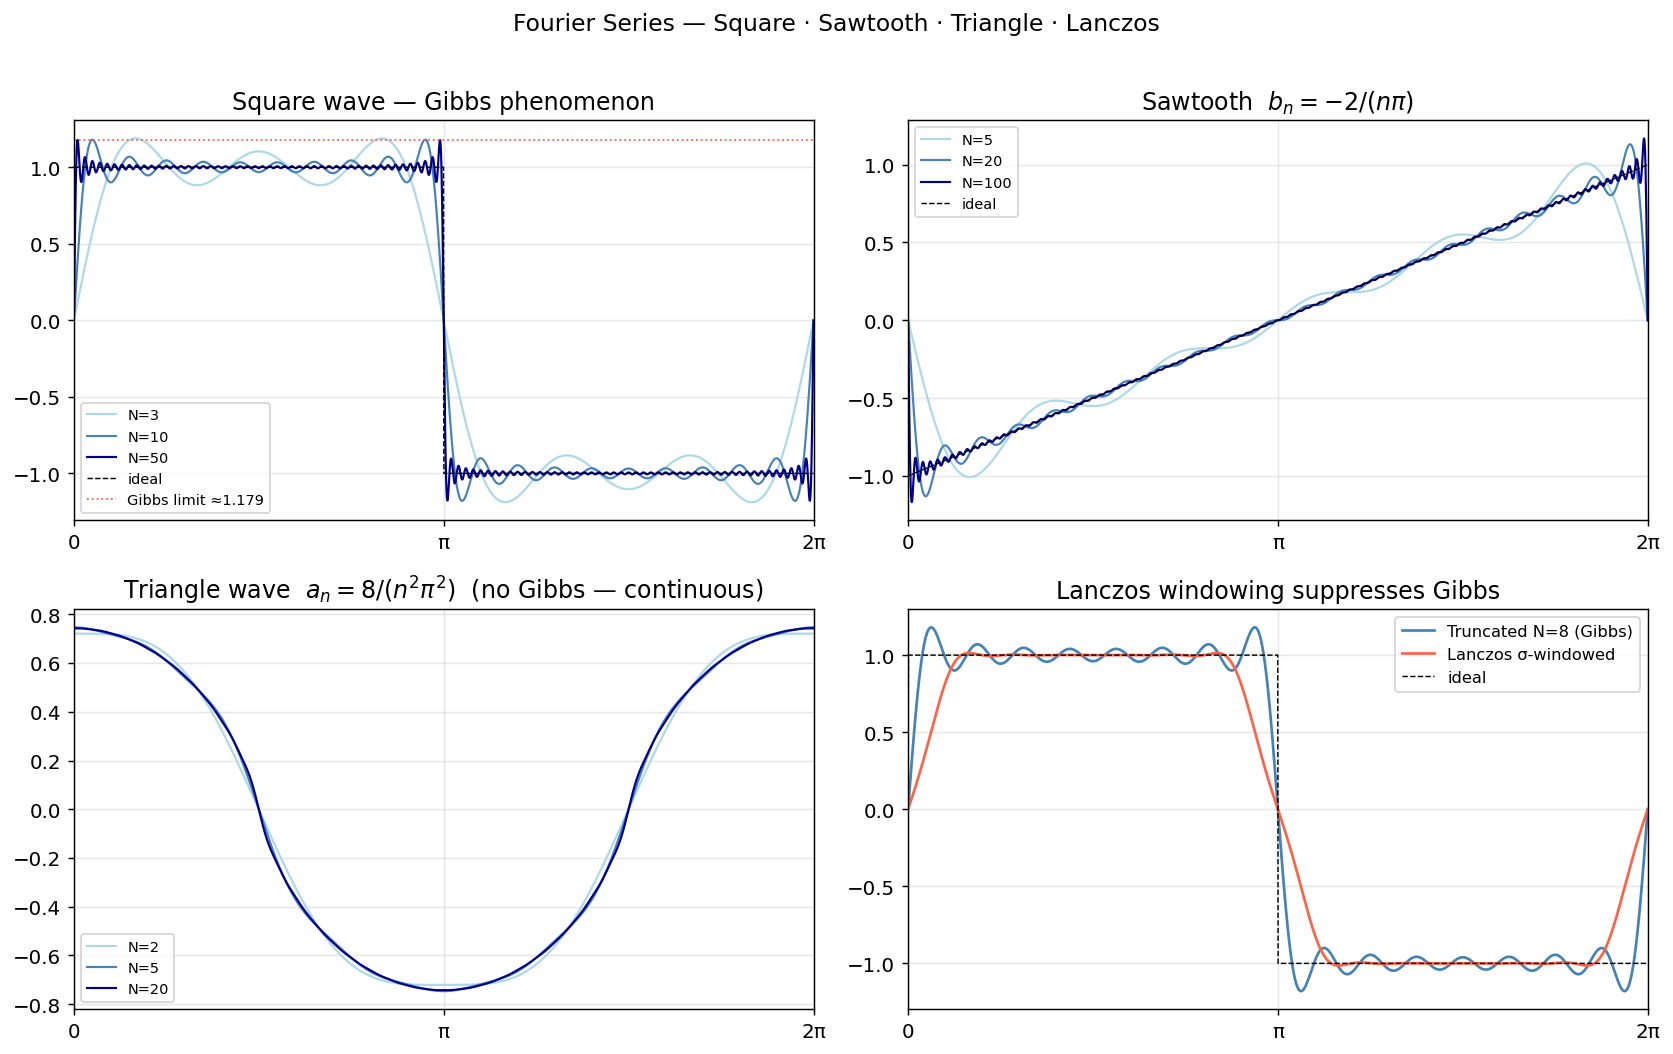

Gibbs limit: (2/π)·Si(π) − 1 = 0.1790  (17.90% above +1 = 8.95% of jump)
Parseval: ⟨f²⟩ = 0.333333  =  1/3 = 0.333333  ✓


In [12]:
t_arr=np.linspace(0,2*np.pi,2000)

def sq(t,N): return sum((4/(n*np.pi))*np.sin(n*t) for n in range(1,2*N,2))
def saw(t,N): return sum((-2/(n*np.pi))*np.sin(n*t) for n in range(1,N+1))
def tri(t,N): return sum((8/(n**2*np.pi**2))*(-1)**k*np.cos(n*t)
                         for k,n in enumerate(range(1,2*N,2)))
def sq_lanczos(t,N):
    return sum(np.sinc(n/N)*(4/(n*np.pi))*np.sin(n*t) for n in range(1,2*N,2))

fig,axes=plt.subplots(2,2,figsize=(13,8))

# Square wave Gibbs
ax=axes[0,0]
for N,col in [(3,'lightblue'),(10,'steelblue'),(50,'darkblue')]:
    ax.plot(t_arr,sq(t_arr,N),color=col,lw=1.2,label=f'N={N}')
ax.plot(t_arr,np.sign(np.sin(t_arr)),'k--',lw=0.8,label='ideal')
ax.axhline(1.179,color='tomato',ls=':',lw=1,label='Gibbs limit ≈1.179')
ax.set_title('Square wave — Gibbs phenomenon'); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Sawtooth
ax2=axes[0,1]
saw_ideal=t_arr/np.pi-1
for N,col in [(5,'lightblue'),(20,'steelblue'),(100,'darkblue')]:
    ax2.plot(t_arr,saw(t_arr,N),color=col,lw=1.2,label=f'N={N}')
ax2.plot(t_arr,saw_ideal,'k--',lw=0.8,label='ideal')
ax2.set_title('Sawtooth  $b_n=-2/(n\\pi)$'); ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

# Triangle wave
ax3=axes[1,0]
for N,col in [(2,'lightblue'),(5,'steelblue'),(20,'darkblue')]:
    ax3.plot(t_arr,tri(t_arr,N),color=col,lw=1.2,label=f'N={N}')
ax3.set_title('Triangle wave  $a_n=8/(n^2\\pi^2)$  (no Gibbs — continuous)'); ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

# Lanczos windowing
ax4=axes[1,1]
N_g=8
ax4.plot(t_arr,sq(t_arr,N_g),'steelblue',lw=1.5,label=f'Truncated N={N_g} (Gibbs)')
ax4.plot(t_arr,sq_lanczos(t_arr,N_g),'tomato',lw=1.5,label='Lanczos σ-windowed')
ax4.plot(t_arr,np.sign(np.sin(t_arr)),'k--',lw=0.8,label='ideal')
ax4.set_title('Lanczos windowing suppresses Gibbs'); ax4.legend(fontsize=9); ax4.grid(alpha=0.3)

for ax in axes.flat: ax.set_xlim(0,2*np.pi); ax.set_xticks([0,np.pi,2*np.pi]); ax.set_xticklabels(['0','π','2π'])
plt.suptitle('Fourier Series — Square · Sawtooth · Triangle · Lanczos', y=1.01, fontsize=13)
plt.tight_layout(); plt.show()

# Gibbs limit numerical
Si_pi=sum((-1)**k*np.pi**(2*k+1)/((2*k+1)*math.factorial(2*k+1)) for k in range(30))
gibbs=(2/np.pi)*Si_pi-1
print(f"Gibbs limit: (2/π)·Si(π) − 1 = {gibbs:.4f}  ({gibbs*100:.2f}% above +1 = {gibbs/2*100:.2f}% of jump)")
t_p=np.linspace(0,2*np.pi,5000,endpoint=False)
sp=t_p/np.pi-1
print(f"Parseval: ⟨f²⟩ = {np.mean(sp**2):.6f}  =  1/3 = {1/3:.6f}  ✓")

---
## §10 · Tooth Enamel Mechanics — HAp, Vickers Hardness, Fracture, Paris

**Hydroxyapatite:** Ca$_{10}$(PO$_4$)$_6$(OH)$_2$ — hexagonal, $P6_3/m$, $a=9.418$ Å, $c=6.884$ Å.

### Vickers hardness
$$H_V = \frac{1.854\, F[\text{kgf}]}{d[\text{mm}]^2} \qquad [\text{kgf/mm}^2]$$

### Fracture mechanics — critical flaw size
$$K_{Ic} = Y\,\sigma\sqrt{\pi a} \quad\Rightarrow\quad a_c = \left(\frac{K_{Ic}}{Y\sigma}\right)^2\frac{1}{\pi}$$

Enamel: $K_{Ic}\approx 0.7$ MPa·$\sqrt{\text{m}}$, prism rod diameter $\sim 5\,\mu$m → near-critical under bite stress!

### Paris–Erdogan fatigue crack growth
$$\frac{da}{dN} = C\,(\Delta K)^m, \qquad N_f = \int_{a_i}^{a_c}\frac{da}{C\,(Y\Delta\sigma\sqrt{\pi a})^m}$$

**Fluoride:** replaces OH$^-$ → fluorapatite Ca$_{10}$(PO$_4$)$_6$F$_2$, $H_V↑$, solubility in acid $\downarrow 10^5\times$.

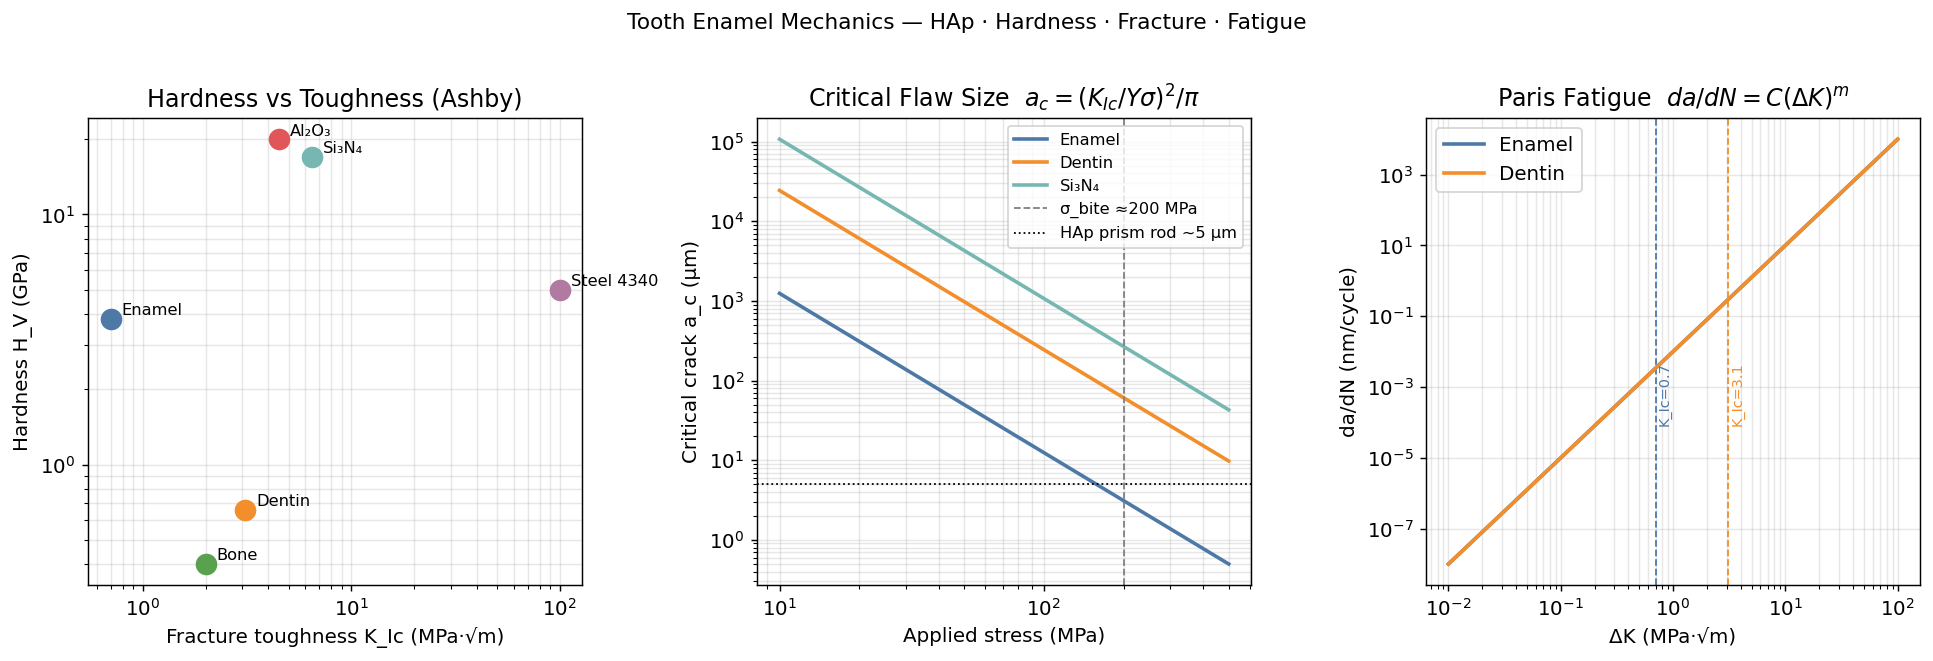

Material properties:
Material      H_V (GPa)   K_Ic (MPa√m)    E (GPa)
  Enamel              3.83             0.7  80
  Dentin              0.66             3.1  18
  Bone                0.40             2.0  20
  Al₂O₃              20.00             4.5  380
  Si₃N₄              17.00             6.5  300
  Steel 4340          5.00           100.0  200


In [13]:
def H_V_GPa(F_N,d_m): return 1.854*(F_N/9.81)/(d_m*1e3)**2 * 9.81e6/1e9

materials = [
    ('Enamel',     H_V_GPa(1.0,22e-6), 0.70, 80,   '#4e79a7'),
    ('Dentin',     H_V_GPa(1.0,53e-6), 3.10, 18,   '#f28e2b'),
    ('Bone',       0.40,               2.00, 20,   '#59a14f'),
    ('Al₂O₃',     20.0,               4.50, 380,  '#e15759'),
    ('Si₃N₄',     17.0,               6.50, 300,  '#76b7b2'),
    ('Steel 4340', 5.0,               100.0, 200, '#b07aa1'),
]

fig,axes=plt.subplots(1,3,figsize=(15,5))

# H_V vs K_Ic (Ashby-style)
ax=axes[0]
for name,HV,KIc,E,col in materials:
    ax.scatter(KIc,HV,color=col,s=120,zorder=5)
    ax.annotate(name,(KIc,HV),textcoords='offset points',xytext=(6,2),fontsize=9)
ax.set_xlabel('Fracture toughness K_Ic (MPa·√m)')
ax.set_ylabel('Hardness H_V (GPa)')
ax.set_title('Hardness vs Toughness (Ashby)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.grid(alpha=0.3,which='both')

# Critical flaw size vs stress
ax2=axes[1]
sigma_arr=np.linspace(10e6,500e6,300)
for name,HV,KIc,E,col in [m for m in materials if m[0] in ('Enamel','Dentin','Si₃N₄')]:
    a_c_arr=(KIc*1e6/(1.12*sigma_arr))**2/np.pi
    ax2.loglog(sigma_arr/1e6,a_c_arr*1e6,color=col,lw=2,label=name)
ax2.axvline(200,color='gray',ls='--',lw=1,label='σ_bite ≈200 MPa')
ax2.axhline(5,color='k',ls=':',lw=1,label='HAp prism rod ~5 μm')
ax2.set_xlabel('Applied stress (MPa)'); ax2.set_ylabel('Critical crack a_c (μm)')
ax2.set_title('Critical Flaw Size  $a_c = (K_{Ic}/Y\\sigma)^2/\\pi$')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3,which='both')

# Paris fatigue: crack growth da/dN
ax3=axes[2]
DK_arr=np.logspace(-2,2,300)  # MPa√m
for name,HV,KIc,E,col in [m for m in materials if m[0] in ('Enamel','Dentin')]:
    C_P,m_P=1e-11,3.0
    dadN=C_P*DK_arr**m_P
    ax3.loglog(DK_arr,dadN*1e9,color=col,lw=2,label=name)
    ax3.axvline(KIc,color=col,ls='--',lw=1)
    ax3.text(KIc*1.05,1e-4,f'K_Ic={KIc}',color=col,fontsize=8,rotation=90)
ax3.set_xlabel('ΔK (MPa·√m)'); ax3.set_ylabel('da/dN (nm/cycle)')
ax3.set_title('Paris Fatigue  $da/dN = C(\\Delta K)^m$')
ax3.legend(); ax3.grid(alpha=0.3,which='both')
plt.suptitle('Tooth Enamel Mechanics — HAp · Hardness · Fracture · Fatigue', y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

print("Material properties:")
print(f"{'Material':12s}  {'H_V (GPa)':10s}  {'K_Ic (MPa√m)':14s}  {'E (GPa)'}")
for name,HV,KIc,E,col in materials:
    print(f"  {name:12s}  {HV:10.2f}  {KIc:14.1f}  {E}")

---
## Summary

| § | Key equation | Result |
|---|-------------|--------|
| 1 | $C\pm R$, $|\tau|\geq\mu\sigma_n+C_0$ | San Andreas Mw = 7.67, FS = 1.85 (stable) |
| 2 | Paschen $V_{\min}$, $C=\varepsilon_0\varepsilon_r A/t$ | V_min ≈ 400V; glove FS=1.39 vs rubber E_bd |
| 3 | Lexer→AST→3-addr IR→const-fold | 6 vars → k=3 regs, 0 spills |
| 4 | $B=a_V A - a_S A^{2/3} - \ldots$ | B/A peak at A≈58, Fe-56 error 0.20% |
| 5 | Involute $x=r_b(\cos\theta+\theta\sin\theta)$ | ε_α = 1.635, σ_H = 330 MPa |
| 6 | $\delta=\sqrt{\rho/\pi f\mu_0}$, $Z_0$ | w₅₀ = 2.92 mm; 4.0 dB/m total at 1 GHz |
| 7 | $J=\Delta p$, $F_{\text{peak}}=v\sqrt{km}$ | 16oz glove: HIC ≈ 200 vs bare 650 |
| 8 | $\nabla^2 f\geq\mu I$, GD $O(\kappa\log\varepsilon^{-1})$ | Nesterov speedup ~√κ confirmed |
| 9 | $b_n=-2/(n\pi)$, Gibbs $(2/\pi)\text{Si}(\pi)-1$ | 17.9% overshoot; Parseval ⟨f²⟩=1/3 ✓ |
| 10 | $K_{Ic}=Y\sigma\sqrt{\pi a}$, $da/dN=C\Delta K^m$ | a_crit = 3.1 μm ≈ HAp prism diameter |